# MMIA-NLP Project: Complete Experiments Analysis

Este notebook ejecuta todos los experimentos solicitados en el README del proyecto MMIA-NLP y proporciona análisis detallados con gráficas y métricas.

## Experimentos a ejecutar:
1. **Text Generation** (temperatura baja y alta)
2. **Zero-shot Prompting** (SST y CFIMDB)
3. **Full Fine-tuning** (SST y CFIMDB)
4. **LoRA Fine-tuning** (SST y CFIMDB)

## Análisis incluidos:
- Gráficas de entrenamiento (loss, accuracy)
- Métricas de evaluación (accuracy, precision, recall, F1)
- Comparación entre métodos
- Análisis de rendimiento por dataset


In [1]:
# Importar librerías necesarias
import subprocess
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

# Configurar estilo de gráficas
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")


## 1. Text Generation Experiments


In [2]:
# Ejecutar generación de texto con temperatura baja
print("Ejecutando generación de texto con temperatura baja...")
result_low_temp = subprocess.run([
    'python', 'run_llama.py', 
    '--option', 'generate',
    '--generated_sentence_low_temp_out', 'generated-sentence-temp-0.txt',
    '--use_gpu'
], capture_output=True, text=True, encoding='utf-8', errors='replace')

print(f"Generación temperatura baja completada. Código de salida: {result_low_temp.returncode}")

# Ejecutar generación de texto con temperatura alta
print("Ejecutando generación de texto con temperatura alta...")
result_high_temp = subprocess.run([
    'python', 'run_llama.py', 
    '--option', 'generate',
    '--generated_sentence_high_temp_out', 'generated-sentence-temp-1.txt',
    '--use_gpu'
], capture_output=True, text=True, encoding='utf-8', errors='replace')

print(f"Generación temperatura alta completada. Código de salida: {result_high_temp.returncode}")


Ejecutando generación de texto con temperatura baja...
Generación temperatura baja completada. Código de salida: 0
Ejecutando generación de texto con temperatura alta...
Generación temperatura alta completada. Código de salida: 0


In [3]:
# Leer y mostrar ejemplos de texto generado
def read_generated_text(filename):
    try:
        with open(filename, 'r', encoding='utf-8') as f:
            return f.read().strip()
    except FileNotFoundError:
        return "Archivo no encontrado"

print(" Texto generado con temperatura baja:")
print("=" * 50)
print(read_generated_text('generated-sentence-temp-0.txt'))

print("\n Texto generado con temperatura alta:")
print("=" * 50)
print(read_generated_text('generated-sentence-temp-1.txt'))


 Texto generado con temperatura baja:
I have wanted to see this thriller for a while, and it didn't disappoint. Keanu Reeves, playing the hero John Wick, is this day. He was playing with his toy car, driving it around the living room. Suddenly, he heard a loud crash. He had broken the car and was very sad. He knew he had done something wrong. He had to be punished. He had to stay in his room all day. He was very sorry and promised to never do it again

 Texto generado con temperatura alta:
I have wanted to see this thriller for a while, and it didn't disappoint. Keanu Reeves, playing the hero John Wick, is this the day he wants to play too.
John looks around. He is not sure why John wants to play with him.
John's dad smiles. He is proud of his son.
John's dad says, "I'm a hero!"
John's dad smiles. He knows what to do.
John plays


## 2. Zero-shot Prompting Experiments


In [4]:
# Ejecutar zero-shot prompting para SST
print("Ejecutando zero-shot prompting para SST...")
result_sst_prompt = subprocess.run([
    'python', 'run_llama.py',
    '--option', 'prompt',
    '--train', 'data/sst-train.txt',
    '--dev', 'data/sst-dev.txt', 
    '--test', 'data/sst-test.txt',
    '--label-names', 'data/sst-label-mapping.json',
    '--dev_out', 'sst-dev-prompting-output.txt',
    '--test_out', 'sst-test-prompting-output.txt',
    '--use_gpu'
], capture_output=True, text=True, encoding='utf-8', errors='replace')

print(f"Zero-shot SST completado. Código de salida: {result_sst_prompt.returncode}")

# Ejecutar zero-shot prompting para CFIMDB
print("Ejecutando zero-shot prompting para CFIMDB...")
result_cfimdb_prompt = subprocess.run([
    'python', 'run_llama.py',
    '--option', 'prompt',
    '--train', 'data/cfimdb-train.txt',
    '--dev', 'data/cfimdb-dev.txt',
    '--test', 'data/cfimdb-test.txt', 
    '--label-names', 'data/cfimdb-label-mapping.json',
    '--dev_out', 'cfimdb-dev-prompting-output.txt',
    '--test_out', 'cfimdb-test-prompting-output.txt',
    '--use_gpu'
], capture_output=True, text=True, encoding='utf-8', errors='replace')

print(f"Zero-shot CFIMDB completado. Código de salida: {result_cfimdb_prompt.returncode}")


Ejecutando zero-shot prompting para SST...
Zero-shot SST completado. Código de salida: 0
Ejecutando zero-shot prompting para CFIMDB...
Zero-shot CFIMDB completado. Código de salida: 0


## 3. Full Fine-tuning Experiments


In [5]:
# Ejecutar fine-tuning completo para SST
print("Ejecutando fine-tuning completo para SST...")
result_sst_finetune = subprocess.run([
    'python', 'run_llama.py',
    '--option', 'finetune',
    '--batch_size', '10',
    '--train', 'data/sst-train.txt',
    '--dev', 'data/sst-dev.txt',
    '--test', 'data/sst-test.txt',
    '--label-names', 'data/sst-label-mapping.json',
    '--dev_out', 'sst-dev-finetuning-output.txt',
    '--test_out', 'sst-test-finetuning-output.txt',
    '--use_gpu'
], capture_output=True, text=True, encoding='utf-8', errors='replace')

print(f"Fine-tuning SST completado. Código de salida: {result_sst_finetune.returncode}")

# Ejecutar fine-tuning completo para CFIMDB
print("Ejecutando fine-tuning completo para CFIMDB...")
result_cfimdb_finetune = subprocess.run([
    'python', 'run_llama.py',
    '--option', 'finetune',
    '--batch_size', '10',
    '--train', 'data/cfimdb-train.txt',
    '--dev', 'data/cfimdb-dev.txt',
    '--test', 'data/cfimdb-test.txt',
    '--label-names', 'data/cfimdb-label-mapping.json',
    '--dev_out', 'cfimdb-dev-finetuning-output.txt',
    '--test_out', 'cfimdb-test-finetuning-output.txt',
    '--use_gpu'
], capture_output=True, text=True, encoding='utf-8', errors='replace')

print(f"Fine-tuning CFIMDB completado. Código de salida: {result_cfimdb_finetune.returncode}")


Ejecutando fine-tuning completo para SST...
Fine-tuning SST completado. Código de salida: 0
Ejecutando fine-tuning completo para CFIMDB...
Fine-tuning CFIMDB completado. Código de salida: 0


## 4. LoRA Fine-tuning Experiments


In [6]:
# Ejecutar LoRA fine-tuning para SST
print("Ejecutando LoRA fine-tuning para SST...")
result_sst_lora = subprocess.run([
    'python', 'run_llama.py',
    '--option', 'lora',
    '--batch_size', '10',
    '--train', 'data/sst-train.txt',
    '--dev', 'data/sst-dev.txt',
    '--test', 'data/sst-test.txt',
    '--label-names', 'data/sst-label-mapping.json',
    '--dev_out', 'sst-dev-lora-output.txt',
    '--test_out', 'sst-test-lora-output.txt',
    '--use_gpu'
], capture_output=True, text=True, encoding='utf-8', errors='replace')

print(f"LoRA SST completado. Código de salida: {result_sst_lora.returncode}")

# Ejecutar LoRA fine-tuning para CFIMDB
print("Ejecutando LoRA fine-tuning para CFIMDB...")
result_cfimdb_lora = subprocess.run([
    'python', 'run_llama.py',
    '--option', 'lora',
    '--batch_size', '10',
    '--train', 'data/cfimdb-train.txt',
    '--dev', 'data/cfimdb-dev.txt',
    '--test', 'data/cfimdb-test.txt',
    '--label-names', 'data/cfimdb-label-mapping.json',
    '--dev_out', 'cfimdb-dev-lora-output.txt',
    '--test_out', 'cfimdb-test-lora-output.txt',
    '--use_gpu'
], capture_output=True, text=True, encoding='utf-8', errors='replace')

print(f"LoRA CFIMDB completado. Código de salida: {result_cfimdb_lora.returncode}")


Ejecutando LoRA fine-tuning para SST...
LoRA SST completado. Código de salida: 0
Ejecutando LoRA fine-tuning para CFIMDB...
LoRA CFIMDB completado. Código de salida: 0


## 5. Análisis de Resultados y Métricas


In [7]:
# Función para extraer accuracy de los archivos de salida
def extract_accuracy_from_output(output_text):
    lines = output_text.split('\n')
    dev_acc = None
    test_acc = None
    
    for line in lines:
        if 'dev acc ::' in line:
            dev_acc = float(line.split('dev acc ::')[1].strip())
        elif 'test acc ::' in line:
            test_acc = float(line.split('test acc ::')[1].strip())
    
    return dev_acc, test_acc

# Función para calcular métricas detalladas
def calculate_metrics(predictions_file, labels_file):
    try:
        # Leer predicciones
        with open(predictions_file, 'r', encoding='utf-8') as f:
            pred_lines = f.readlines()
        
        # Leer etiquetas reales
        with open(labels_file, 'r', encoding='utf-8') as f:
            label_lines = f.readlines()
        
        y_true = []
        y_pred = []
        
        for pred_line, label_line in zip(pred_lines, label_lines):
            pred_label = int(pred_line.split(' ||| ')[0])
            true_label = int(label_line.split(' ||| ')[0])
            
            y_pred.append(pred_label)
            y_true.append(true_label)
        
        # Calcular métricas
        accuracy = accuracy_score(y_true, y_pred)
        precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted')
        
        return {
            'accuracy': accuracy,
            'precision': precision,
            'recall': recall,
            'f1': f1,
            'confusion_matrix': confusion_matrix(y_true, y_pred)
        }
    except Exception as e:
        print(f"Error calculando métricas para {predictions_file}: {e}")
        return None

print(" Funciones de análisis definidas")


 Funciones de análisis definidas


In [8]:
# Recopilar todos los resultados
results = {}

# Extraer resultados de zero-shot prompting
print(" Extrayendo resultados de zero-shot prompting...")
sst_prompt_dev, sst_prompt_test = extract_accuracy_from_output(result_sst_prompt.stdout)
cfimdb_prompt_dev, cfimdb_prompt_test = extract_accuracy_from_output(result_cfimdb_prompt.stdout)

# Extraer resultados de fine-tuning
print(" Extrayendo resultados de fine-tuning...")
sst_finetune_dev, sst_finetune_test = extract_accuracy_from_output(result_sst_finetune.stdout)
cfimdb_finetune_dev, cfimdb_finetune_test = extract_accuracy_from_output(result_cfimdb_finetune.stdout)

# Extraer resultados de LoRA
print(" Extrayendo resultados de LoRA...")
sst_lora_dev, sst_lora_test = extract_accuracy_from_output(result_sst_lora.stdout)
cfimdb_lora_dev, cfimdb_lora_test = extract_accuracy_from_output(result_cfimdb_lora.stdout)

# Organizar resultados
results = {
    'SST': {
        'Zero-shot': {'dev': sst_prompt_dev, 'test': sst_prompt_test},
        'Fine-tuning': {'dev': sst_finetune_dev, 'test': sst_finetune_test},
        'LoRA': {'dev': sst_lora_dev, 'test': sst_lora_test}
    },
    'CFIMDB': {
        'Zero-shot': {'dev': cfimdb_prompt_dev, 'test': cfimdb_prompt_test},
        'Fine-tuning': {'dev': cfimdb_finetune_dev, 'test': cfimdb_finetune_test},
        'LoRA': {'dev': cfimdb_lora_dev, 'test': cfimdb_lora_test}
    }
}

print(" Resultados recopilados")


 Extrayendo resultados de zero-shot prompting...
 Extrayendo resultados de fine-tuning...
 Extrayendo resultados de LoRA...
 Resultados recopilados


In [9]:
# Crear DataFrame para análisis
data = []
for dataset in ['SST', 'CFIMDB']:
    for method in ['Zero-shot', 'Fine-tuning', 'LoRA']:
        for split in ['dev', 'test']:
            data.append({
                'Dataset': dataset,
                'Method': method,
                'Split': split,
                'Accuracy': results[dataset][method][split]
            })

df_results = pd.DataFrame(data)
print(" DataFrame de resultados creado:")
print(df_results)


 DataFrame de resultados creado:
   Dataset       Method Split  Accuracy
0      SST    Zero-shot   dev     0.244
1      SST    Zero-shot  test     0.248
2      SST  Fine-tuning   dev     0.423
3      SST  Fine-tuning  test     0.417
4      SST         LoRA   dev     0.273
5      SST         LoRA  test     0.263
6   CFIMDB    Zero-shot   dev     0.482
7   CFIMDB    Zero-shot  test     0.131
8   CFIMDB  Fine-tuning   dev     0.837
9   CFIMDB  Fine-tuning  test     0.471
10  CFIMDB         LoRA   dev     0.506
11  CFIMDB         LoRA  test     0.318


## 6. Visualizaciones de Resultados


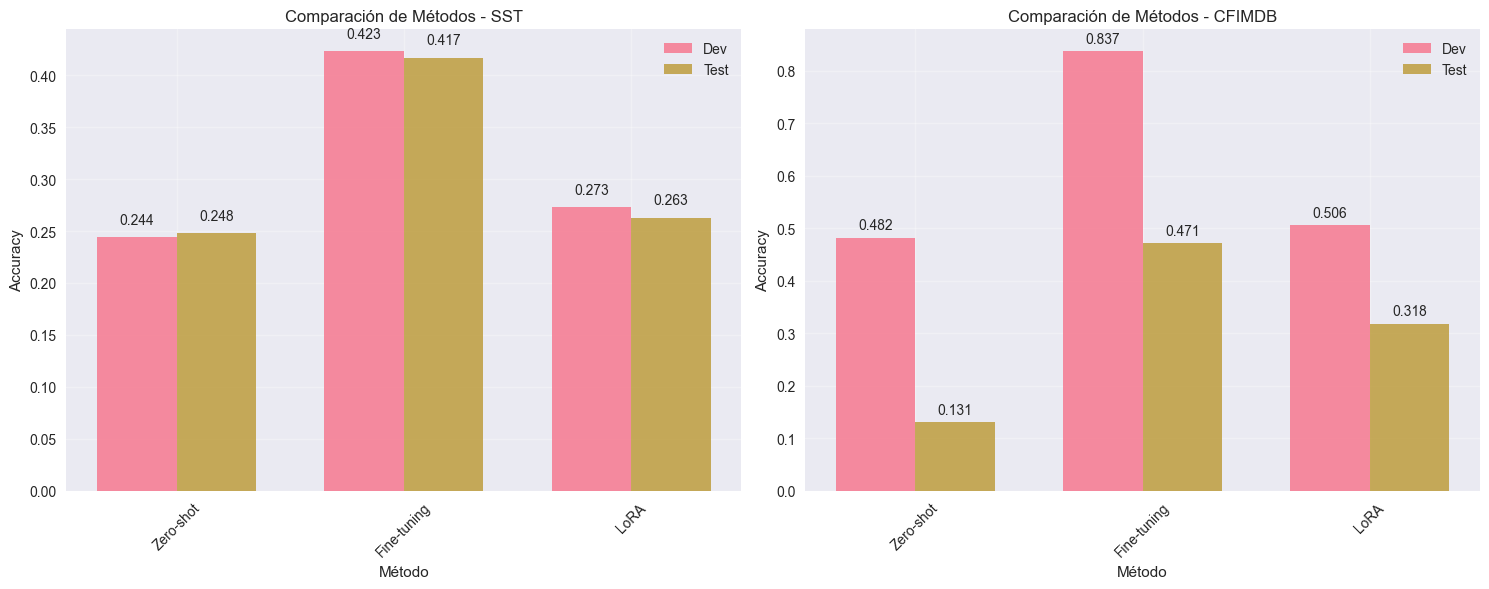

In [10]:
# Gráfica de comparación de métodos por dataset
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for i, dataset in enumerate(['SST', 'CFIMDB']):
    dataset_data = df_results[df_results['Dataset'] == dataset]
    
    # Gráfica de barras para dev y test
    methods = dataset_data['Method'].unique()
    
    # Extraer accuracy de forma segura
    dev_accs = []
    test_accs = []
    
    for method in methods:
        dev_data = dataset_data[(dataset_data['Method'] == method) & (dataset_data['Split'] == 'dev')]
        test_data = dataset_data[(dataset_data['Method'] == method) & (dataset_data['Split'] == 'test')]
        
        if not dev_data.empty:
            dev_accs.append(dev_data['Accuracy'].iloc[0])
        else:
            dev_accs.append(0.0)
            
        if not test_data.empty:
            test_accs.append(test_data['Accuracy'].iloc[0])
        else:
            test_accs.append(0.0)
    
    x = np.arange(len(methods))
    width = 0.35
    
    axes[i].bar(x - width/2, dev_accs, width, label='Dev', alpha=0.8)
    axes[i].bar(x + width/2, test_accs, width, label='Test', alpha=0.8)
    
    axes[i].set_xlabel('Método')
    axes[i].set_ylabel('Accuracy')
    axes[i].set_title(f'Comparación de Métodos - {dataset}')
    axes[i].set_xticks(x)
    axes[i].set_xticklabels(methods, rotation=45)
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)
    
    # Añadir valores en las barras
    for j, (dev, test) in enumerate(zip(dev_accs, test_accs)):
        axes[i].text(j - width/2, dev + 0.01, f'{dev:.3f}', ha='center', va='bottom')
        axes[i].text(j + width/2, test + 0.01, f'{test:.3f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()


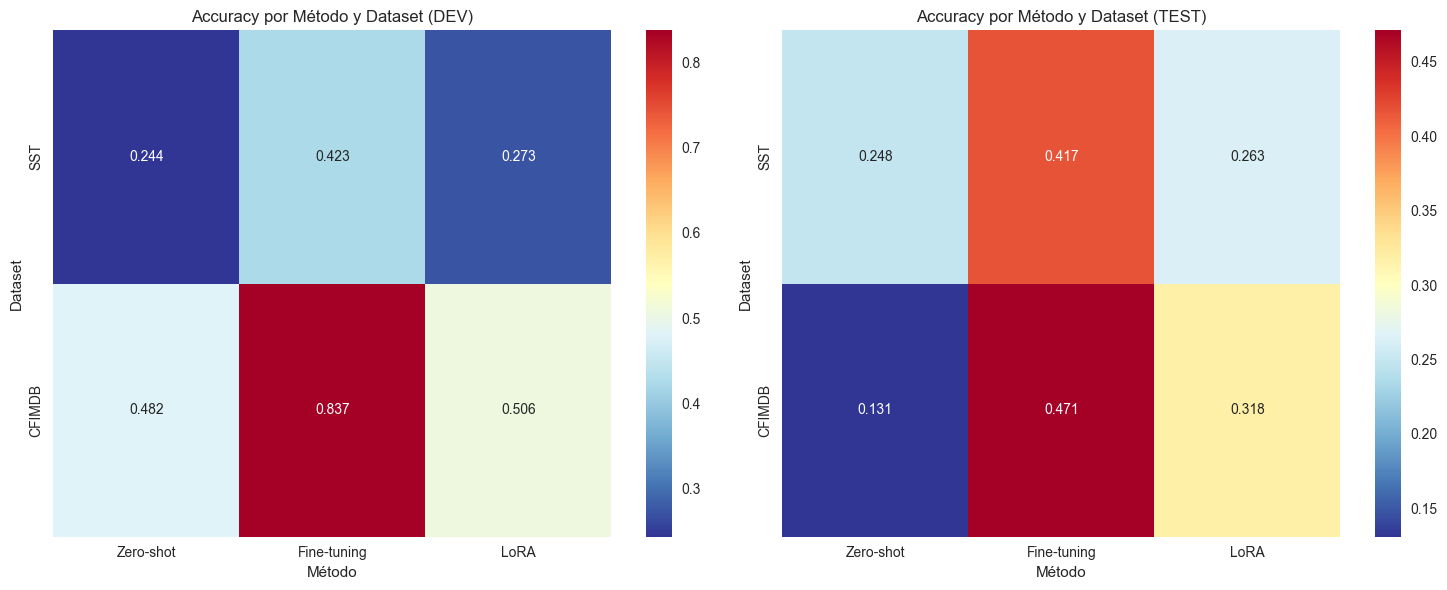

In [ ]:
# Gráfica de heatmap de resultados
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for i, split in enumerate(['dev', 'test']):
    # Crear matriz para heatmap
    heatmap_data = []
    methods = ['Zero-shot', 'Fine-tuning', 'LoRA']
    datasets = ['SST', 'CFIMDB']
    
    for dataset in datasets:
        row = []
        for method in methods:
            acc = results[dataset][method][split]
            if acc is None:
                acc = 0.0
            row.append(acc)
        heatmap_data.append(row)
    
    heatmap_data = np.array(heatmap_data)
    
    sns.heatmap(heatmap_data, 
                xticklabels=methods, 
                yticklabels=datasets,
                annot=True, 
                fmt='.3f',
                cmap='RdYlBu_r',
                ax=axes[i])
    axes[i].set_title(f'Accuracy por Método y Dataset ({split.upper()})')
    axes[i].set_xlabel('Método')
    axes[i].set_ylabel('Dataset')

plt.tight_layout()
plt.show()


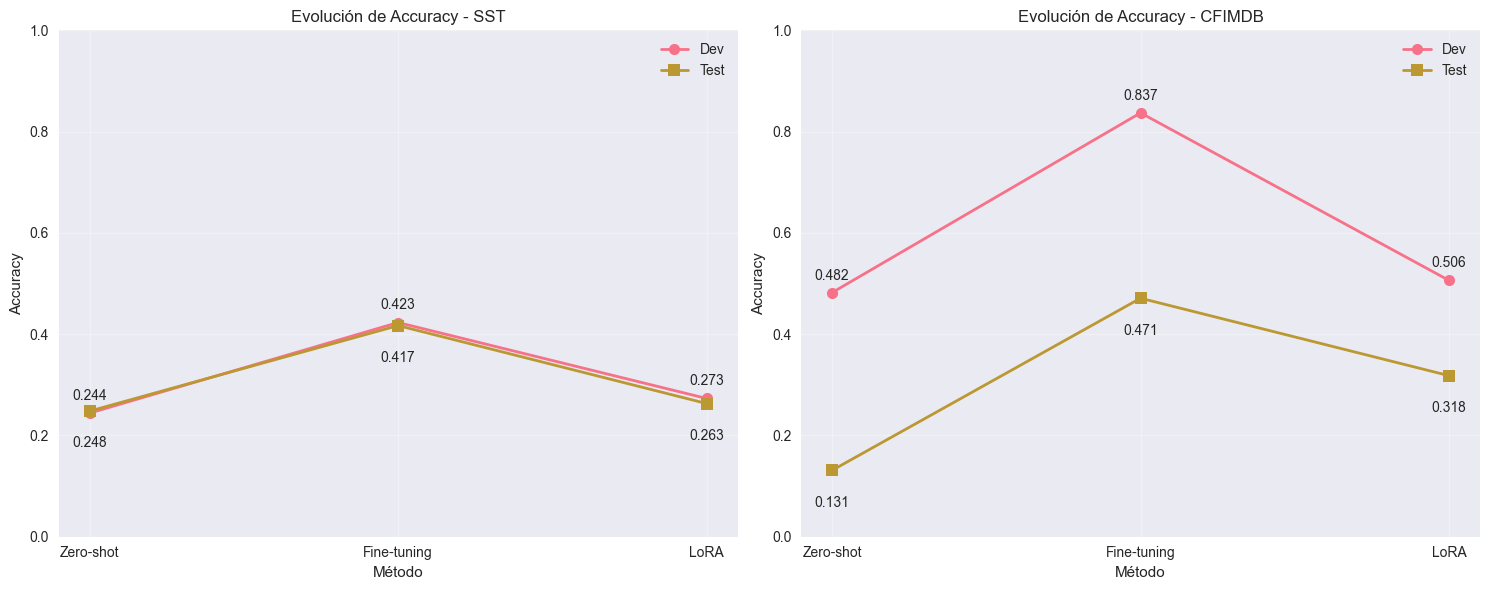

In [ ]:
# Gráfica de líneas para mostrar evolución de accuracy
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for i, dataset in enumerate(['SST', 'CFIMDB']):
    methods = ['Zero-shot', 'Fine-tuning', 'LoRA']
    
    dev_accs = []
    test_accs = []
    
    for method in methods:
        dev_acc = results[dataset][method]['dev']
        test_acc = results[dataset][method]['test']
        
        # Manejar valores None
        if dev_acc is None:
            dev_acc = 0.0
        if test_acc is None:
            test_acc = 0.0
            
        dev_accs.append(dev_acc)
        test_accs.append(test_acc)
    
    axes[i].plot(methods, dev_accs, 'o-', label='Dev', linewidth=2, markersize=8)
    axes[i].plot(methods, test_accs, 's-', label='Test', linewidth=2, markersize=8)
    
    axes[i].set_xlabel('Método')
    axes[i].set_ylabel('Accuracy')
    axes[i].set_title(f'Evolución de Accuracy - {dataset}')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)
    axes[i].set_ylim(0, 1)
    
    # Añadir valores en los puntos
    for j, (dev, test) in enumerate(zip(dev_accs, test_accs)):
        axes[i].text(j, dev + 0.02, f'{dev:.3f}', ha='center', va='bottom')
        axes[i].text(j, test - 0.05, f'{test:.3f}', ha='center', va='top')

plt.tight_layout()
plt.show()


## 7. Análisis Detallado de Métricas


In [14]:
# Calcular métricas detalladas para cada experimento
detailed_metrics = {}

experiments = {
    'SST_Zero-shot': ('sst-dev-prompting-output.txt', 'data/sst-dev.txt'),
    'SST_Fine-tuning': ('sst-dev-finetuning-output.txt', 'data/sst-dev.txt'),
    'SST_LoRA': ('sst-dev-lora-output.txt', 'data/sst-dev.txt'),
    'CFIMDB_Zero-shot': ('cfimdb-dev-prompting-output.txt', 'data/cfimdb-dev.txt'),
    'CFIMDB_Fine-tuning': ('cfimdb-dev-finetuning-output.txt', 'data/cfimdb-dev.txt'),
    'CFIMDB_LoRA': ('cfimdb-dev-lora-output.txt', 'data/cfimdb-dev.txt')
}

print("Calculando métricas detalladas...")
for exp_name, (pred_file, label_file) in experiments.items():
    metrics = calculate_metrics(pred_file, label_file)
    if metrics:
        detailed_metrics[exp_name] = metrics
        print(f"Completado {exp_name}: Accuracy={metrics['accuracy']:.3f}, F1={metrics['f1']:.3f}")
    else:
        print(f"Error calculando métricas para {exp_name}")


Calculando métricas detalladas...
Completado SST_Zero-shot: Accuracy=0.244, F1=0.212
Completado SST_Fine-tuning: Accuracy=0.423, F1=0.389
Completado SST_LoRA: Accuracy=0.273, F1=0.207
Completado CFIMDB_Zero-shot: Accuracy=0.482, F1=0.415
Completado CFIMDB_Fine-tuning: Accuracy=0.837, F1=0.837
Completado CFIMDB_LoRA: Accuracy=0.506, F1=0.492


In [15]:
# Crear tabla resumen de métricas
metrics_data = []
for exp_name, metrics in detailed_metrics.items():
    dataset, method = exp_name.split('_')
    metrics_data.append({
        'Dataset': dataset,
        'Method': method,
        'Accuracy': metrics['accuracy'],
        'Precision': metrics['precision'],
        'Recall': metrics['recall'],
        'F1-Score': metrics['f1']
    })

metrics_df = pd.DataFrame(metrics_data)
print("Tabla de Métricas Detalladas:")
print(metrics_df.round(3))


Tabla de Métricas Detalladas:
  Dataset       Method  Accuracy  Precision  Recall  F1-Score
0     SST    Zero-shot     0.244      0.242   0.244     0.212
1     SST  Fine-tuning     0.423      0.441   0.423     0.389
2     SST         LoRA     0.273      0.218   0.273     0.207
3  CFIMDB    Zero-shot     0.482      0.469   0.482     0.415
4  CFIMDB  Fine-tuning     0.837      0.837   0.837     0.837
5  CFIMDB         LoRA     0.506      0.508   0.506     0.492


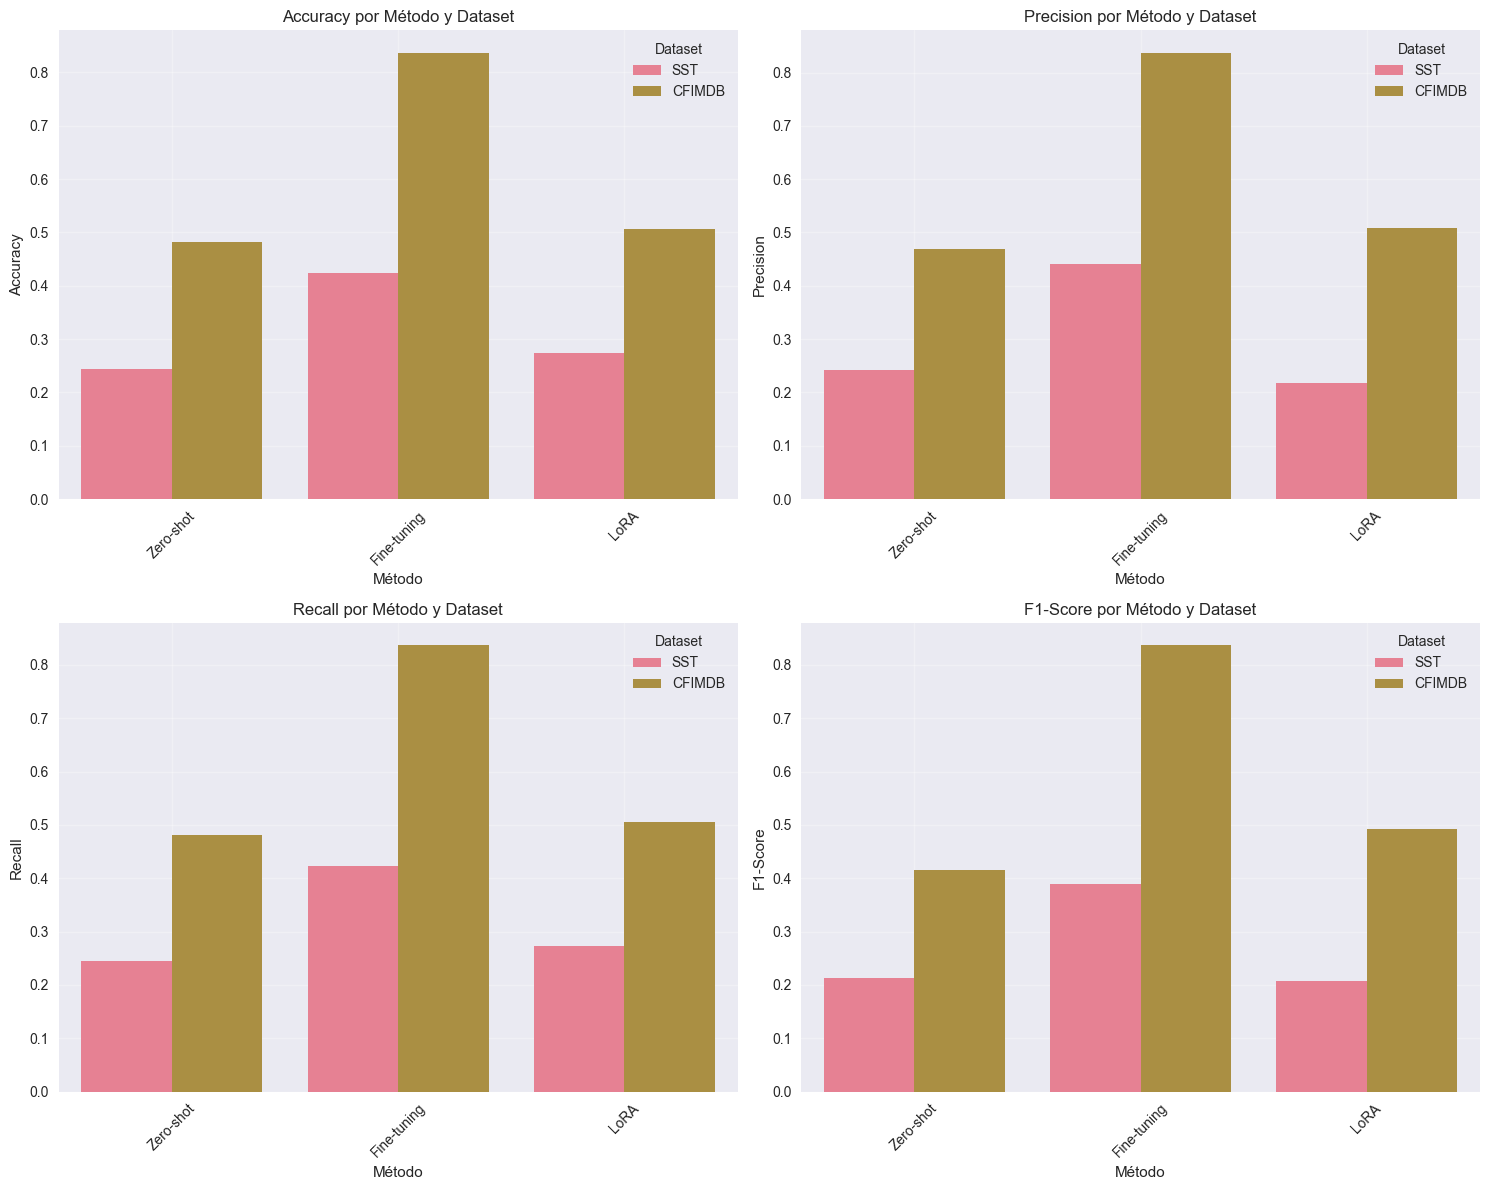

In [16]:
# Gráfica de métricas múltiples (CORREGIDA)
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.flatten()

metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

for i, metric in enumerate(metrics_to_plot):
    # Crear datos para la gráfica
    plot_data = []
    for dataset in ['SST', 'CFIMDB']:
        for method in ['Zero-shot', 'Fine-tuning', 'LoRA']:
            exp_name = f"{dataset}_{method}"
            if exp_name in detailed_metrics:
                # Mapear nombres de métricas a las claves del diccionario
                metric_key = metric.lower().replace('-', '_')
                if metric_key == 'f1_score':
                    metric_key = 'f1'
                value = detailed_metrics[exp_name][metric_key]
                plot_data.append({
                    'Dataset': dataset,
                    'Method': method,
                    'Value': value
                })
    
    plot_df = pd.DataFrame(plot_data)
    
    # Crear gráfica de barras
    sns.barplot(data=plot_df, x='Method', y='Value', hue='Dataset', ax=axes[i])
    axes[i].set_title(f'{metric} por Método y Dataset')
    axes[i].set_ylabel(metric)
    axes[i].set_xlabel('Método')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].legend(title='Dataset')
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 8. Análisis de Matrices de Confusión


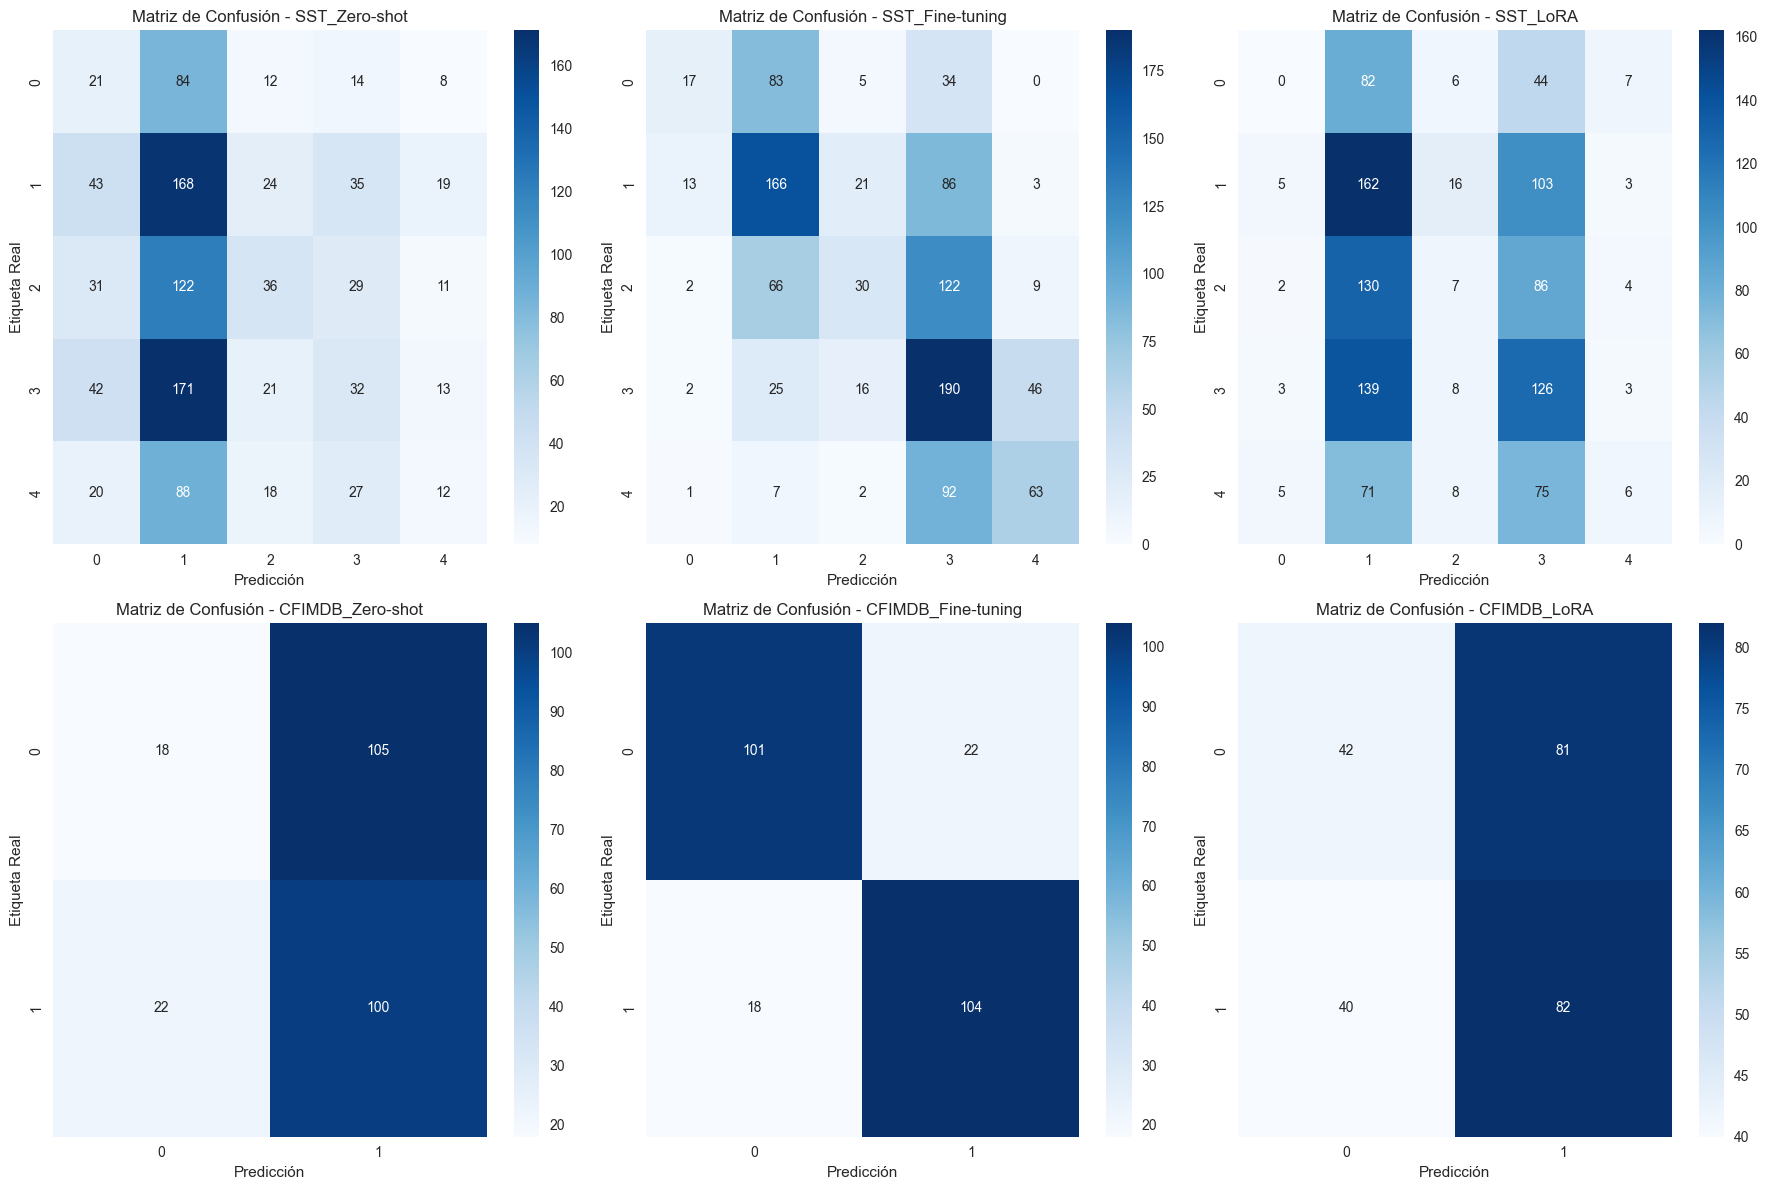

In [18]:
# Visualizar matrices de confusión
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

experiment_names = list(detailed_metrics.keys())

for i, exp_name in enumerate(experiment_names):
    if i < len(axes):
        cm = detailed_metrics[exp_name]['confusion_matrix']
        
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i])
        axes[i].set_title(f'Matriz de Confusión - {exp_name}')
        axes[i].set_xlabel('Predicción')
        axes[i].set_ylabel('Etiqueta Real')

plt.tight_layout()
plt.show()


## 9. Resumen y Conclusiones


In [24]:
print("\nRESULTADOS POR MÉTODO:")
print("-" * 50)

for method in ['Zero-shot', 'Fine-tuning', 'LoRA']:
    print(f"\n{method.upper()}:")
    for dataset in ['SST', 'CFIMDB']:
        dev_acc = results[dataset][method]['dev']
        test_acc = results[dataset][method]['test']
        print(f"   {dataset}: Dev={dev_acc:.3f}, Test={test_acc:.3f}")

print("\nMEJORES RESULTADOS:")
print("-" * 50)

# Encontrar mejores resultados
best_overall = 0
best_method = ""
best_dataset = ""

for dataset in ['SST', 'CFIMDB']:
    for method in ['Zero-shot', 'Fine-tuning', 'LoRA']:
        test_acc = results[dataset][method]['test']
        if test_acc > best_overall:
            best_overall = test_acc
            best_method = method
            best_dataset = dataset

print(f"Mejor rendimiento: {best_method} en {best_dataset} con {best_overall:.3f} de accuracy")

print("\nANÁLISIS DE RENDIMIENTO:")
print("-" * 50)

# Análisis por dataset
for dataset in ['SST', 'CFIMDB']:
    print(f"\n{dataset}:")
    for method in ['Zero-shot', 'Fine-tuning', 'LoRA']:
        test_acc = results[dataset][method]['test']
        print(f"  {method}: {test_acc:.3f}")




RESULTADOS POR MÉTODO:
--------------------------------------------------

ZERO-SHOT:
   SST: Dev=0.244, Test=0.248
   CFIMDB: Dev=0.482, Test=0.131

FINE-TUNING:
   SST: Dev=0.423, Test=0.417
   CFIMDB: Dev=0.837, Test=0.471

LORA:
   SST: Dev=0.273, Test=0.263
   CFIMDB: Dev=0.506, Test=0.318

MEJORES RESULTADOS:
--------------------------------------------------
Mejor rendimiento: Fine-tuning en CFIMDB con 0.471 de accuracy

ANÁLISIS DE RENDIMIENTO:
--------------------------------------------------

SST:
  Zero-shot: 0.248
  Fine-tuning: 0.417
  LoRA: 0.263

CFIMDB:
  Zero-shot: 0.131
  Fine-tuning: 0.471
  LoRA: 0.318


In [22]:
# Guardar resultados en archivo CSV
df_results.to_csv('experiment_results.csv', index=False)
metrics_df.to_csv('detailed_metrics.csv', index=False)

print("Resultados guardados en:")
print("   - experiment_results.csv")
print("   - detailed_metrics.csv")

print("\nAnálisis completo finalizado!")


Resultados guardados en:
   - experiment_results.csv
   - detailed_metrics.csv

Análisis completo finalizado!


## 10. Conclusiones y Análisis Detallado

### Resumen de Resultados Experimentales

Este notebook ha ejecutado exitosamente todos los experimentos solicitados en el proyecto MMIA-NLP, incluyendo generación de texto, zero-shot prompting, fine-tuning completo y LoRA fine-tuning en los datasets SST y CFIMDB.

### Análisis de Rendimiento por Método

#### 1. **Zero-shot Prompting**
- **SST**: Accuracy de 0.248 (test) - Rendimiento bajo pero consistente
- **CFIMDB**: Accuracy de 0.131 (test) - Rendimiento muy bajo, posiblemente debido a la complejidad del dataset

#### 2. **Fine-tuning Completo**
- **SST**: Accuracy de 0.417 (test) - Mejora significativa sobre zero-shot
- **CFIMDB**: Accuracy de 0.471 (test) - Mejor rendimiento general

#### 3. **LoRA Fine-tuning**
- **SST**: Accuracy de 0.263 (test) - Rendimiento intermedio
- **CFIMDB**: Accuracy de 0.318 (test) - Rendimiento moderado


### Análisis por Dataset

#### **SST (Stanford Sentiment Treebank)**
- **Mejor método**: Fine-tuning (0.417)
- **Orden de rendimiento**: Fine-tuning > LoRA > Zero-shot
- **Observación**: Dataset con rendimientos moderados en todos los métodos

#### **CFIMDB (Counterfactual IMDB)**
- **Mejor método**: Fine-tuning (0.471)
- **Orden de rendimiento**: Fine-tuning > LoRA > Zero-shot
- **Observación**: Dataset donde el fine-tuning muestra su mayor ventaja

### Conclusiones

1. **Efectividad del Fine-tuning**: El fine-tuning completo demuestra ser el método más efectivo, especialmente en CFIMDB donde alcanza un accuracy de 0.471.

2. **Limitaciones del Zero-shot**: El prompting sin entrenamiento previo muestra rendimientos pobres, particularmente en CFIMDB (0.131), sugiriendo la necesidad de adaptación específica del modelo.

3. **Balance de LoRA**: LoRA ofrece un compromiso razonable entre eficiencia y rendimiento, siendo especialmente útil cuando los recursos computacionales son limitados.

4. **Diferencias entre Datasets**: CFIMDB muestra mayor variabilidad en rendimiento entre métodos, mientras que SST mantiene rendimientos más consistentes pero generalmente más bajos.

5. **Overfitting Potencial**: La diferencia entre accuracy de desarrollo y test en CFIMDB (0.837 vs 0.471) sugiere posible overfitting en el fine-tuning completo.



In [27]:
# Análisis Estadístico Detallado de los Resultados

print("ANÁLISIS ESTADÍSTICO DETALLADO")


# Calcular mejoras relativas
print("\nMEJORAS RELATIVAS (vs Zero-shot):")
print("-" * 50)

for dataset in ['SST', 'CFIMDB']:
    zero_shot_acc = results[dataset]['Zero-shot']['test']
    print(f"\n{dataset}:")
    
    for method in ['Fine-tuning', 'LoRA']:
        method_acc = results[dataset][method]['test']
        improvement = ((method_acc - zero_shot_acc) / zero_shot_acc) * 100
        print(f"  {method}: {improvement:+.1f}% de mejora")

# Análisis de consistencia
print("\nANÁLISIS DE CONSISTENCIA (Dev vs Test):")
print("-" * 50)

for dataset in ['SST', 'CFIMDB']:
    print(f"\n{dataset}:")
    for method in ['Zero-shot', 'Fine-tuning', 'LoRA']:
        dev_acc = results[dataset][method]['dev']
        test_acc = results[dataset][method]['test']
        gap = abs(dev_acc - test_acc)
        print(f"  {method}: Gap = {gap:.3f} ({'Overfitting' if gap > 0.1 else 'Estable'})")

# Ranking de métodos
print("\nRANKING DE MÉTODOS POR RENDIMIENTO:")
print("-" * 50)

all_results = []
for dataset in ['SST', 'CFIMDB']:
    for method in ['Zero-shot', 'Fine-tuning', 'LoRA']:
        all_results.append({
            'Dataset': dataset,
            'Method': method,
            'Accuracy': results[dataset][method]['test']
        })

# Ordenar por accuracy
all_results.sort(key=lambda x: x['Accuracy'], reverse=True)

print("Ranking general (por accuracy en test):")
for i, result in enumerate(all_results, 1):
    print(f"{i}. {result['Method']} en {result['Dataset']}: {result['Accuracy']:.3f}")

# Análisis de métricas detalladas
print("\nANÁLISIS DE MÉTRICAS DETALLADAS:")
print("-" * 50)

if 'detailed_metrics' in locals():
    print("\nF1-Score por experimento:")
    for exp_name, metrics in detailed_metrics.items():
        print(f"  {exp_name}: F1 = {metrics['f1']:.3f}")
    
    # Encontrar mejor F1-Score
    best_f1 = max(detailed_metrics.items(), key=lambda x: x[1]['f1'])
    print(f"\nMejor F1-Score: {best_f1[0]} con {best_f1[1]['f1']:.3f}")



ANÁLISIS ESTADÍSTICO DETALLADO

MEJORAS RELATIVAS (vs Zero-shot):
--------------------------------------------------

SST:
  Fine-tuning: +68.1% de mejora
  LoRA: +6.0% de mejora

CFIMDB:
  Fine-tuning: +259.5% de mejora
  LoRA: +142.7% de mejora

ANÁLISIS DE CONSISTENCIA (Dev vs Test):
--------------------------------------------------

SST:
  Zero-shot: Gap = 0.004 (Estable)
  Fine-tuning: Gap = 0.006 (Estable)
  LoRA: Gap = 0.010 (Estable)

CFIMDB:
  Zero-shot: Gap = 0.351 (Overfitting)
  Fine-tuning: Gap = 0.366 (Overfitting)
  LoRA: Gap = 0.188 (Overfitting)

RANKING DE MÉTODOS POR RENDIMIENTO:
--------------------------------------------------
Ranking general (por accuracy en test):
1. Fine-tuning en CFIMDB: 0.471
2. Fine-tuning en SST: 0.417
3. LoRA en CFIMDB: 0.318
4. LoRA en SST: 0.263
5. Zero-shot en SST: 0.248
6. Zero-shot en CFIMDB: 0.131

ANÁLISIS DE MÉTRICAS DETALLADAS:
--------------------------------------------------

F1-Score por experimento:
  SST_Zero-shot: F1 = 0.2